# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Jet astrofísicos, principios

In [ ]:
import pymcel as pc
from pymcel import constantes as const
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


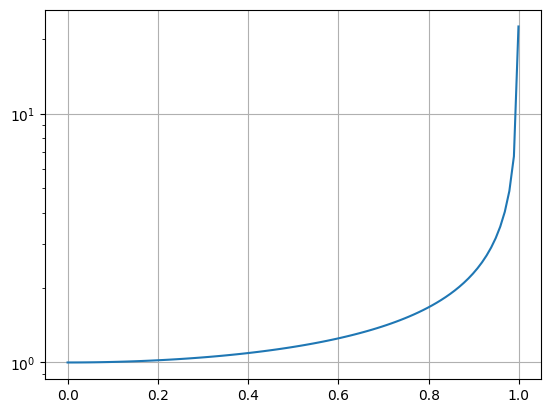

In [ ]:
betas = np.linspace(0, 0.999, 100)
gammas = 1 / np.sqrt(1 - betas**2)
plt.semilogy(betas, gammas)
plt.grid()

## Unidades

Las unidades en EM son las unidades gaussianas, unidades electromagnéticas absolutas, se las inventaron en el XIX y era muy difícil, siempre se utilizaba un objeto, pe. un imán. Gauss invento la idea de que las unidades fueran absolutas en cualquier lugar del universo:

$$
F = \frac{q_1 q_2}{4\pi \epsilon_0 r^2}
$$

Inventemos unas unidades en las cuales:

$$
F' = \frac{q'_1 q'_2}{r'^2}
$$

Cuáles son las unidades de $q$:

$$
[q] = \sqrt{[F]} [r]
$$
 
Si escojo un sistema de unidades $U_L, U_T, U_M, U_F, U_Q$, etc. puedo escribir la carga en el nuevo sistema de unidades así $q = q' U_Q$. Si usamos esto para escribir la fuerza:

$$
F'U_F = \frac{q'_1 U_Q q'_2 U_Q}{4\pi \epsilon_0 r'^2 U_L^2}
$$

Si usamos el hecho de que $F' = q'_1 q'_2/r'^2$. 

$$
U_F = \frac{U_Q U_Q}{4\pi \epsilon_0 U_L^2}
$$

Las unidades de carga en este sistema serán:

$$
U_Q = U_L \sqrt{U_F 4\pi\epsilon_0}
$$



In [ ]:
eps0 = const.eps0
UL = 100e3 # 100 km, simulando un disco de acreción alrededor de estrella
UM = const.m_e
# UT = ??

# Unidades relativistas: c = 1 que implica c = UL / UT
UT = UL / const.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2
UF = UM * UA

# Unidadas gaussianas
UQ = UL * np.sqrt(UF * 4*np.pi*eps0)
UE = UF / UQ
UB = UE / UV 

C = 1


## Tensor de Faraday

In [ ]:
def tensor_faraday_campo_uniforme(B0):
    Ex = Ey = Ez = 0
    Bx = By = 0
    Bz = B0

    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F

In [ ]:
tensor_faraday_campo_uniforme(1)

array([[ 0,  0,  0,  0],
       [ 0,  0, -1,  0],
       [ 0,  1,  0,  0],
       [ 0,  0,  0,  0]])

## Ecuación de movimiento de una carga

In [ ]:
def edm_relativista(tau, Ys, m, q, B0):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3

    F = tensor_faraday_campo_uniforme(B0)
    
    # U_nu = g_mu_nu * U^mu = diag(1, -1, -1, -1) * U^mu
    Usub = np.array([U0, -U1, -U2, -U3])

    f = q/C * F @ Usub

    dU0_dtau = f[0] / m 
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m

    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau, 
                     dU0_dtau, dU1_dtau, dU2_dtau, dU3_dtau])

In [ ]:
edm_relativista(0, [0,0,0,0,1,1,1,1], 1, 1, 1)

array([ 1.,  1.,  1.,  1.,  0.,  1., -1.,  0.])

Condiciones iniciales:

In [ ]:
# En coordenadas temporales y espaciales
t0 = 0
r0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 0.5, 0.2])

# En coordenadas espaciotemporales
x0 = np.array([C*t0, r0[0], r0[1], r0[2]])
gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0, 
               gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]])

# Condiciones iniciales ahora si
Ys0 = np.concatenate((x0, U0))

Integración:

In [ ]:
from scipy.integrate import solve_ivp

m = 1
q = 1
B0 = 1
taus = np.linspace(0, 10, 1000)
solucion = solve_ivp(
    edm_relativista,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m, q, B0),
    method='Radau'
)

Tenemos que recuperar las coordenadas espaciales y temporales

In [ ]:
!pip install -Uq nbformat

In [ ]:
ts = solucion.y[0] / C
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode='lines',
            line=dict(width=4, color=ts, colorscale='Viridis'),
            name='Trayectoria'
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='data'
    ),
    template='plotly_white'
)

fig.show()

## Campo magnético helicoidal

Campo magnético helicoidal:

$$
B_r = 0 \\
B_z = B_0 \\
B_\phi = \frac{B_1}{r}
$$ 

Convertirlo a cartesianas:

$$
B_x = B_r \cos\phi - B_\phi \sin\phi\\
B_y = B_r \sin\phi + B_\phi \cos\phi\\
B_z = B_z
$$

In [ ]:
def tensor_faraday_campo_helicoidal(B0, B1, x, y, z):
    Ex = Ey = Ez = 0
    Bx = By = 0
    
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    
    Bx = -B1/r * np.sin(phi)
    By = B1/r * np.cos(phi)
    Bz = B0

    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F

def edm_relativista(tau, Ys, m, q, B0, B1):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3

    F = tensor_faraday_campo_helicoidal(B0, B1, x1, x2, x3)
    
    # U_nu = g_mu_nu * U^mu = diag(1, -1, -1, -1) * U^mu
    Usub = np.array([U0, -U1, -U2, -U3])

    f = q/C * F @ Usub

    dU0_dtau = f[0] / m 
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m

    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau, 
                     dU0_dtau, dU1_dtau, dU2_dtau, dU3_dtau])

# En coordenadas temporales y espaciales
t0 = 0
r0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 0.2, 0.1])

# En coordenadas espaciotemporales
x0 = np.array([C*t0, r0[0], r0[1], r0[2]])
gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0, 
               gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]])

# Condiciones iniciales ahora si
Ys0 = np.concatenate((x0, U0))

from scipy.integrate import solve_ivp

m = 1
q = 1
B0 = 0.1
B1 = 2
taus = np.linspace(0, 300, 1000)
solucion = solve_ivp(
    edm_relativista,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m, q, B0, B1),
    method='Radau'
)

ts = solucion.y[0] / C
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode='lines',
            line=dict(width=4, color=ts, colorscale='Viridis'),
            name='Trayectoria'
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='data'
    ),
    template='plotly_white'
)

fig.show()